<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-6/ML_LAB_6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Laboratory: Principal Component Interpretation

This notebook aims to interpret a given Principal Component Analysis (PCA) loading matrix to identify the most important variables contributing to each principal component. The analysis focuses on the magnitude of loadings to determine variable importance.

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================
# 2. CREATE PCA LOADING DATASET
# ============================================
data = {
    'Variable': ['Climate', 'Housing', 'Health', 'Crime', 'Transportation', 'Education', 'Arts', 'Recreation', 'Economy'],
    'PC1': [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    'PC2': [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.402, 0.150],
    'PC3': [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239]
}
df_pca_loadings = pd.DataFrame(data)

principal_components = ['PC1', 'PC2', 'PC3']

In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================
display(df_pca_loadings)

,Variable,PC1,PC2,PC3
0,Climate,0.190,0.017,0.207
1,Housing,0.544,0.020,0.204
2,Health,0.782,-0.605,0.144
3,Crime,0.365,0.294,0.585
4,Transportation,0.585,0.085,0.234
5,Education,0.394,-0.273,0.027
6,Arts,0.985,0.126,-0.111
7,Recreation,0.520,0.402,0.519
8,Economy,0.142,0.150,0.239


In [4]:
# ============================================
# 4. CALCULATE ABSOLUTE LOADINGS
# ============================================
df_absolute_loadings = df_pca_loadings.copy()
for pc in principal_components:
    df_absolute_loadings[pc] = df_absolute_loadings[pc].abs()

display(df_absolute_loadings)

,Variable,PC1,PC2,PC3
0,Climate,0.190,0.017,0.207
1,Housing,0.544,0.020,0.204
2,Health,0.782,0.605,0.144
3,Crime,0.365,0.294,0.585
4,Transportation,0.585,0.085,0.234
5,Education,0.394,0.273,0.027
6,Arts,0.985,0.126,0.111
7,Recreation,0.520,0.402,0.519
8,Economy,0.142,0.150,0.239


In [5]:
# ============================================
# 5. IDENTIFY DOMINANT VARIABLE FOR PC1
# ============================================
max_abs_loading_pc1 = df_absolute_loadings['PC1'].max()
dominant_variable_pc1 = df_absolute_loadings.loc[df_absolute_loadings['PC1'] == max_abs_loading_pc1, 'Variable'].iloc[0]
original_loading_pc1 = df_pca_loadings.loc[df_pca_loadings['Variable'] == dominant_variable_pc1, 'PC1'].iloc[0]

print(f"PC1: The variable with the largest absolute loading is '{dominant_variable_pc1}' with an original loading of {original_loading_pc1:.3f} and an absolute loading of {max_abs_loading_pc1:.3f}.")

PC1: The variable with the largest absolute loading is 'Arts' with an original loading of 0.985 and an absolute loading of 0.985.


In [6]:
# ============================================
# 6. IDENTIFY DOMINANT VARIABLE FOR PC2
# ============================================
max_abs_loading_pc2 = df_absolute_loadings['PC2'].max()
dominant_variable_pc2 = df_absolute_loadings.loc[df_absolute_loadings['PC2'] == max_abs_loading_pc2, 'Variable'].iloc[0]
original_loading_pc2 = df_pca_loadings.loc[df_pca_loadings['Variable'] == dominant_variable_pc2, 'PC2'].iloc[0]

print(f"PC2: The variable with the largest absolute loading is '{dominant_variable_pc2}' with an original loading of {original_loading_pc2:.3f} and an absolute loading of {max_abs_loading_pc2:.3f}.")

PC2: The variable with the largest absolute loading is 'Health' with an original loading of -0.605 and an absolute loading of 0.605.


In [7]:
# ============================================
# 7. IDENTIFY DOMINANT VARIABLE FOR PC3
# ============================================
max_abs_loading_pc3 = df_absolute_loadings['PC3'].max()
dominant_variable_pc3 = df_absolute_loadings.loc[df_absolute_loadings['PC3'] == max_abs_loading_pc3, 'Variable'].iloc[0]
original_loading_pc3 = df_pca_loadings.loc[df_pca_loadings['Variable'] == dominant_variable_pc3, 'PC3'].iloc[0]

print(f"PC3: The variable with the largest absolute loading is '{dominant_variable_pc3}' with an original loading of {original_loading_pc3:.3f} and an absolute loading of {max_abs_loading_pc3:.3f}.")

PC3: The variable with the largest absolute loading is 'Crime' with an original loading of 0.585 and an absolute loading of 0.585.


In [8]:
# ============================================
# 8. DISPLAY PRINCIPAL COMPONENT RESULTS
# ============================================
results_data = [
    {
        'Principal Component': 'PC1',
        'Variable with Highest Loading': dominant_variable_pc1,
        'Loading': original_loading_pc1,
        'Absolute Loading': max_abs_loading_pc1
    },
    {
        'Principal Component': 'PC2',
        'Variable with Highest Loading': dominant_variable_pc2,
        'Loading': original_loading_pc2,
        'Absolute Loading': max_abs_loading_pc2
    },
    {
        'Principal Component': 'PC3',
        'Variable with Highest Loading': dominant_variable_pc3,
        'Loading': original_loading_pc3,
        'Absolute Loading': max_abs_loading_pc3
    }
]
df_results = pd.DataFrame(results_data)
display(df_results)

,Principal Component,Variable with Highest Loading,Loading,Absolute Loading
0,PC1,Arts,0.985,0.985
1,PC2,Health,-0.605,0.605
2,PC3,Crime,0.585,0.585


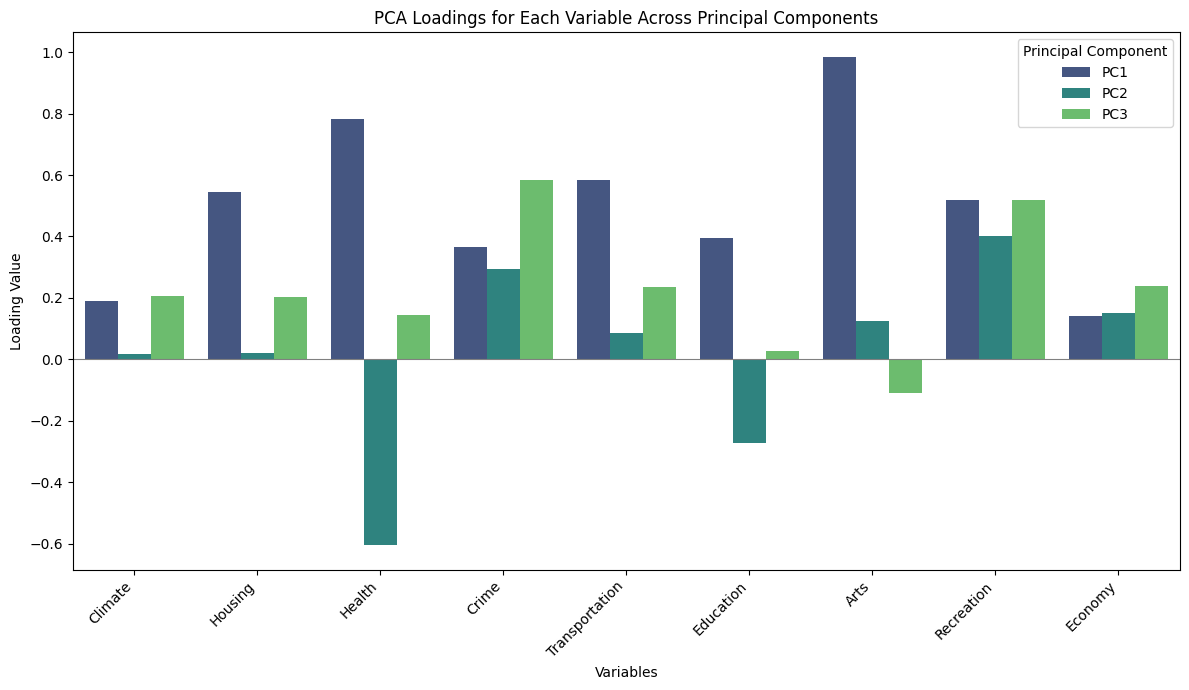

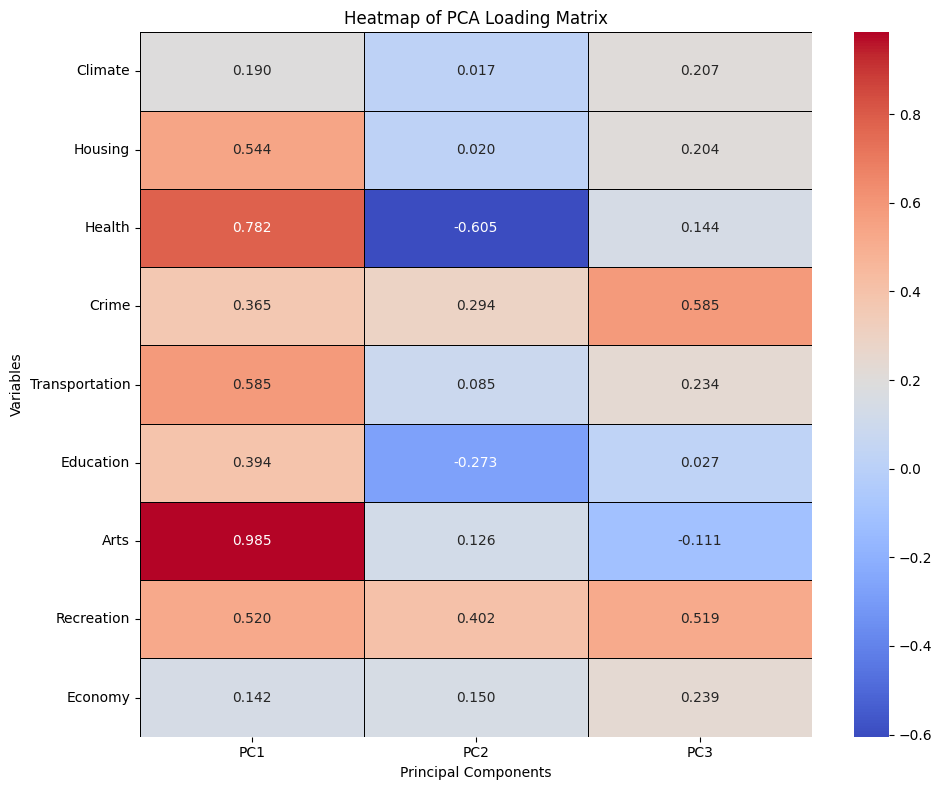

In [9]:
# ============================================
# 9. VISUALIZE PCA LOADINGS
# ============================================

# Grouped Bar Chart
df_long = df_pca_loadings.melt(id_vars='Variable', var_name='Principal Component', value_name='Loading')
plt.figure(figsize=(12, 7))
sns.barplot(x='Variable', y='Loading', hue='Principal Component', data=df_long, palette='viridis')
plt.title('PCA Loadings for Each Variable Across Principal Components')
plt.xlabel('Variables')
plt.ylabel('Loading Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linewidth=0.8)
plt.legend(title='Principal Component')
plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_pca_loadings.set_index('Variable'), annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5, linecolor='black')
plt.title('Heatmap of PCA Loading Matrix')
plt.xlabel('Principal Components')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

## Observation

The interpretation of PCA loadings is crucial for understanding how original variables contribute to each principal component. A larger absolute loading value indicates that the corresponding variable has a stronger influence or contribution to that particular principal component. This means that changes in that variable are highly correlated with changes in the principal component.

Conversely, the sign of the loading (positive or negative) indicates the direction of the relationship. A positive loading means that an increase in the variable's value is associated with an increase in the principal component's value, and vice versa for a negative loading. However, the strength of the contribution is solely determined by the magnitude (absolute value) of the loading, not its sign. It is important to look at the absolute value to identify the most influential variables.

## Conclusion

Based on the analysis of the absolute PCA loading values:

*   **PC1:** The variable **Arts** (loading = 0.985) contributes most strongly to Principal Component 1. This indicates that PC1 is primarily driven by factors related to 'Arts'.
*   **PC2:** The variable **Health** (loading = -0.605) contributes most strongly to Principal Component 2. The negative sign implies an inverse relationship; an increase in 'Health' related factors would lead to a decrease in PC2, but its absolute magnitude (0.605) confirms its significant contribution.
*   **PC3:** The variable **Crime** (loading = 0.585) contributes most strongly to Principal Component 3. This suggests that PC3 largely captures variations associated with 'Crime'.